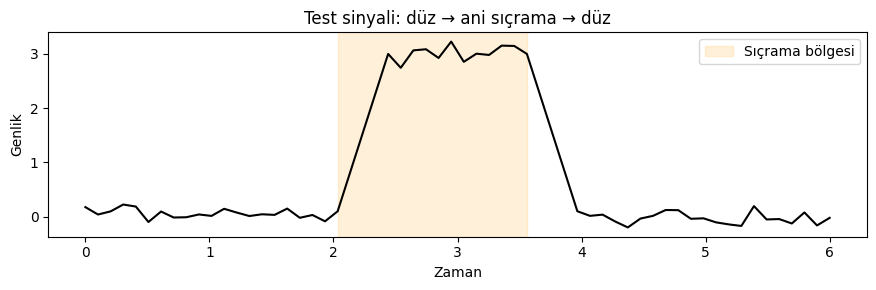

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

np.random.seed(0)
torch.manual_seed(0)

T = 60
t = np.linspace(0, 6, T)

# Ani sıçramalı sentetik "EEG-benzeri" sinyal: düz bölge + ani patlama + tekrar düz
signal = np.concatenate([
    0.1*np.random.randn(20),
    np.linspace(0.1, 3.0, 5),      # ani yükseliş
    3.0 + 0.1*np.random.randn(10), # yüksek platoda kalış
    np.linspace(3.0, 0.1, 5),      # ani düşüş
    0.1*np.random.randn(20),
])

plt.figure(figsize=(9,3))
plt.plot(t, signal, color='black')
plt.axvspan(t[20], t[35], color='orange', alpha=0.15, label='Sıçrama bölgesi')
plt.title("Test sinyali: düz → ani sıçrama → düz")
plt.xlabel("Zaman")
plt.ylabel("Genlik")
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

def gru_step(x_t, h_prev, W, U, b):
    Wr,Wz,Wh = W; Ur,Uz,Uh = U; br,bz,bh = b
    r_t = sigmoid(Wr*x_t + Ur*h_prev + br)
    z_t = sigmoid(Wz*x_t + Uz*h_prev + bz)
    h_tilde = np.tanh(Wh*x_t + Uh*(r_t*h_prev) + bh)
    h_t = (1-z_t)*h_tilde + z_t*h_prev
    return h_t, r_t, z_t

W = (0.5, 0.5, 0.5); U = (0.5, 0.5, 0.5); b = (0.0, 0.0, 0.0)

h = 0.0
hidden_states, reset_gates, update_gates = [], [], []
for x_t in signal:
    h, r_t, z_t = gru_step(x_t, h, W, U, b)
    hidden_states.append(h)
    reset_gates.append(r_t)
    update_gates.append(z_t)

Girdi shape: torch.Size([1, 60, 1])
Output (tüm zaman adımları) shape: torch.Size([1, 60, 8])
h_n (son gizli durum) shape: torch.Size([1, 1, 8])


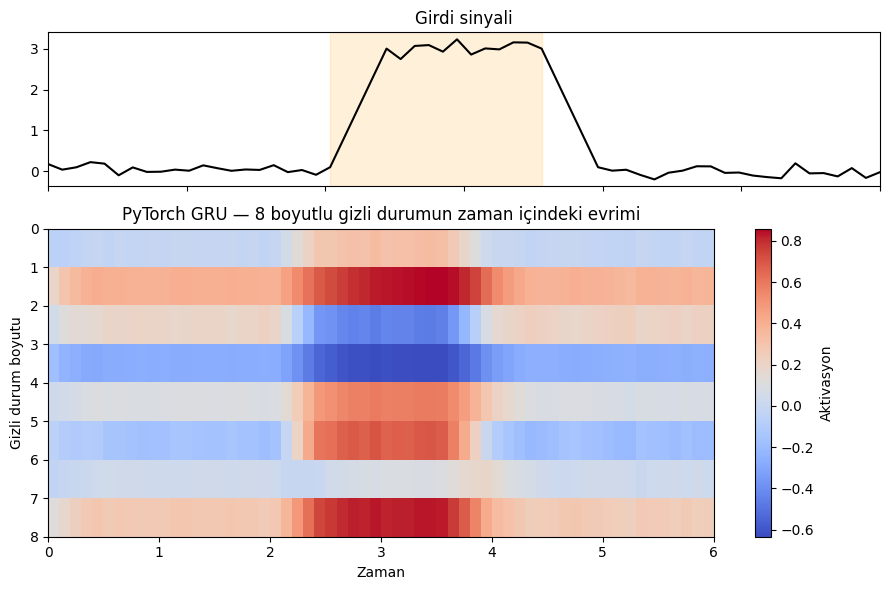

In [3]:
x_tensor = torch.tensor(signal, dtype=torch.float32).view(1, T, 1)

gru = nn.GRU(input_size=1, hidden_size=8, batch_first=True)
output, h_n = gru(x_tensor)

print("Girdi shape:", x_tensor.shape)
print("Output (tüm zaman adımları) shape:", output.shape)
print("h_n (son gizli durum) shape:", h_n.shape)

hidden_over_time = output.squeeze(0).detach().numpy().T  # (8, T)

fig, axes = plt.subplots(2, 1, figsize=(9,6), sharex=True,
                          gridspec_kw={'height_ratios':[1,2]})
axes[0].plot(t, signal, color='black')
axes[0].axvspan(t[20], t[35], color='orange', alpha=0.15)
axes[0].set_title("Girdi sinyali")

im = axes[1].imshow(hidden_over_time, aspect='auto', cmap='coolwarm',
                     extent=[t[0], t[-1], 8, 0])
axes[1].set_title("PyTorch GRU — 8 boyutlu gizli durumun zaman içindeki evrimi")
axes[1].set_ylabel("Gizli durum boyutu")
axes[1].set_xlabel("Zaman")
fig.colorbar(im, ax=axes[1], label="Aktivasyon")
plt.tight_layout()
plt.show()

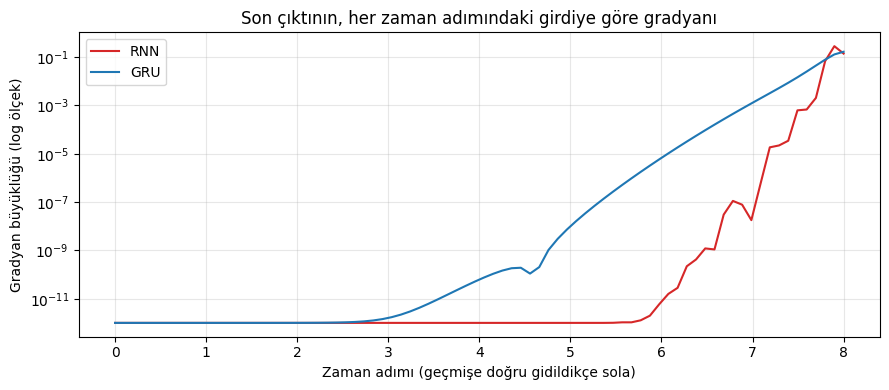

In [4]:
torch.manual_seed(1)
T2 = 80
t2 = np.linspace(0, 8, T2)
sig2 = np.sin(t2)
x2 = torch.tensor(sig2, dtype=torch.float32).view(1, T2, 1).requires_grad_(True)

rnn = nn.RNN(input_size=1, hidden_size=8, batch_first=True)
gru2 = nn.GRU(input_size=1, hidden_size=8, batch_first=True)

def grad_norms_over_time(model, x):
    x = x.clone().detach().requires_grad_(True)
    out, _ = model(x)
    loss = out[0, -1, :].sum()          # sadece SON zaman adımının çıktısı
    loss.backward()
    grads = x.grad[0, :, 0].abs().numpy()  # her zaman adımına gelen gradyan
    return grads

grads_rnn = grad_norms_over_time(rnn, x2)
grads_gru = grad_norms_over_time(gru2, x2)

plt.figure(figsize=(9,4))
plt.semilogy(t2, grads_rnn + 1e-12, label='RNN', color='tab:red')
plt.semilogy(t2, grads_gru + 1e-12, label='GRU', color='tab:blue')
plt.xlabel("Zaman adımı (geçmişe doğru gidildikçe sola)")
plt.ylabel("Gradyan büyüklüğü (log ölçek)")
plt.title("Son çıktının, her zaman adımındaki girdiye göre gradyanı")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()